# South African post-Apartheid Labor Outcomes

## 2011 Census Data

The original study used sex, race, years of education employment status, and log income. 

Link: https://www.datafirst.uct.ac.za/dataportal/index.php/catalog/485/data-dictionary/F4?file_name=sa-census-2011-person-v2-20150825

The identified relevant columns were:

- F03_SEX (1: Male, 2: Female)
- P01_YEAR
- P05_POP_GROUP (1: Black African, 2: Colored, 3: Indian or Asian, 4: White, 5: Other)
- P16_INCOME (1: No income, 2-12: R 1 - R 2457601, 99: Unspecified)
- P20_EDULEVEL (0-28: Grade 0 - Higher degree, 29: Other, 98: No Schooling)
- P23A_EMPLOYMENTSTATUS (1: Yes, 2: No, 3: Do not know)

In [32]:
# load libraries
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
import rdrobust
from stargazer.stargazer import Stargazer
import io

In [33]:
file_path = 'data/sa-census-2011-person-prov-1to5-v2-20150825-stata/sa-census-2011-person-prov-1to5-v1.2-20150825.dta'
cols = ['P01_YEAR', 'F03_SEX', 'P05_POP_GROUP', 'P16_INCOME', 'P20_EDULEVEL', 'P23A_EMPLOYMENTSTATUS']

reader = pd.read_stata(
    file_path, 
    columns=cols,
    chunksize=100000, 
    convert_categoricals=False
)

df_list = []
for chunk in reader:
    chunk = chunk[(chunk['P16_INCOME'] != 99) & (chunk['P23A_EMPLOYMENTSTATUS'] != 3)] # do not keep unspecified income (339531) or unknown employment status (3222)
    for col in chunk.columns:
        chunk[col] = pd.to_numeric(chunk[col], downcast='integer')
        
    df_list.append(chunk)


df = pd.concat(df_list, ignore_index=True)

# categorical variable mapping
race_map = {1: 'Black African', 2: 'Coloured', 3: 'Indian/Asian', 4: 'White', 5: 'Other'}
emp_map = {1: 'Employed', 2: 'Unemployed'}
gen_map = {1: 'Male', 2: 'Female'}

df['F03_SEX'] = df['F03_SEX'].map(gen_map).astype('category')
df['P16_INCOME'] = df['P16_INCOME'].astype('category')
df['P20_EDULEVEL'] = df['P20_EDULEVEL'].astype('category')
df['P05_POP_GROUP'] = df['P05_POP_GROUP'].map(race_map).astype('category')
df['P23A_EMPLOYMENTSTATUS'] = df['P23A_EMPLOYMENTSTATUS'].map(emp_map).astype('category')

In [4]:
df.head()

,P01_YEAR,F03_SEX,P05_POP_GROUP,P16_INCOME,P20_EDULEVEL,P23A_EMPLOYMENTSTATUS
0,1957,Female,Coloured,4.0,7.0,Employed
1,1978,Male,Coloured,1.0,8.0,Unemployed
2,1987,Female,Coloured,1.0,6.0,Unemployed
3,2007,Female,Coloured,2.0,NaN,NaN
4,2010,Male,Coloured,2.0,NaN,NaN


In [5]:
df.describe()

,P01_YEAR
count,2.078515e+06
mean,1.982209e+03
std,2.034389e+01
min,1.891000e+03
25%,1.969000e+03
50%,1.986000e+03
75%,1.999000e+03
max,2.011000e+03


In [6]:
df.isna().sum()

P01_YEAR                      0
F03_SEX                       0
P05_POP_GROUP                 0
P16_INCOME                45227
P20_EDULEVEL             258004
P23A_EMPLOYMENTSTATUS    650218
dtype: int64

**Data Cleaning**

- Filtered data for "White" and "Coloured" persons only
- Mapped income levels to the midpoint of each range 
- Applied log transform to income

In [34]:
# income data wrangling. . . saddle up cowboy
df_filtered = df[df['P05_POP_GROUP'].isin(['Coloured', 'White'])].copy()

midpoint_map = {
    1: 0,            # No income
    2: 2400,         # R 1 - R 4,800
    3: 7200,         # R 4,801 - R 9,600
    4: 14400,        # R 9,601 - R 19,200
    5: 28800,        # R 19,201 - R 38,400
    6: 57600,        # R 38,401 - R 76,800
    7: 115200,       # R 76,801 - R 153,600
    8: 230400,       # R 153,601 - R 307,200
    9: 460800,       # R 307,201 - R 614,400
    10: 921600,      # R 614,401 - R 1,228,800
    11: 1843200,     # R 1,228,801 - R 2,457,600
    12: 3686400      # R 2,457,601 or more (Lower bound * 1.5)
}
# apply the map
df_filtered['real_income'] = df_filtered['P16_INCOME'].map(midpoint_map).astype(float)

# log income o'clock
df_filtered['log_income'] = np.log1p(df_filtered['real_income'])

df_filtered.head()

,P01_YEAR,F03_SEX,P05_POP_GROUP,P16_INCOME,P20_EDULEVEL,P23A_EMPLOYMENTSTATUS,real_income,log_income
0,1957,Female,Coloured,4.0,7.0,Employed,14400.0,9.575053
1,1978,Male,Coloured,1.0,8.0,Unemployed,0.0,0.000000
2,1987,Female,Coloured,1.0,6.0,Unemployed,0.0,0.000000
3,2007,Female,Coloured,2.0,NaN,NaN,2400.0,7.783641
4,2010,Male,Coloured,2.0,NaN,NaN,2400.0,7.783641


**Sex-separated Log Income Density Plots**

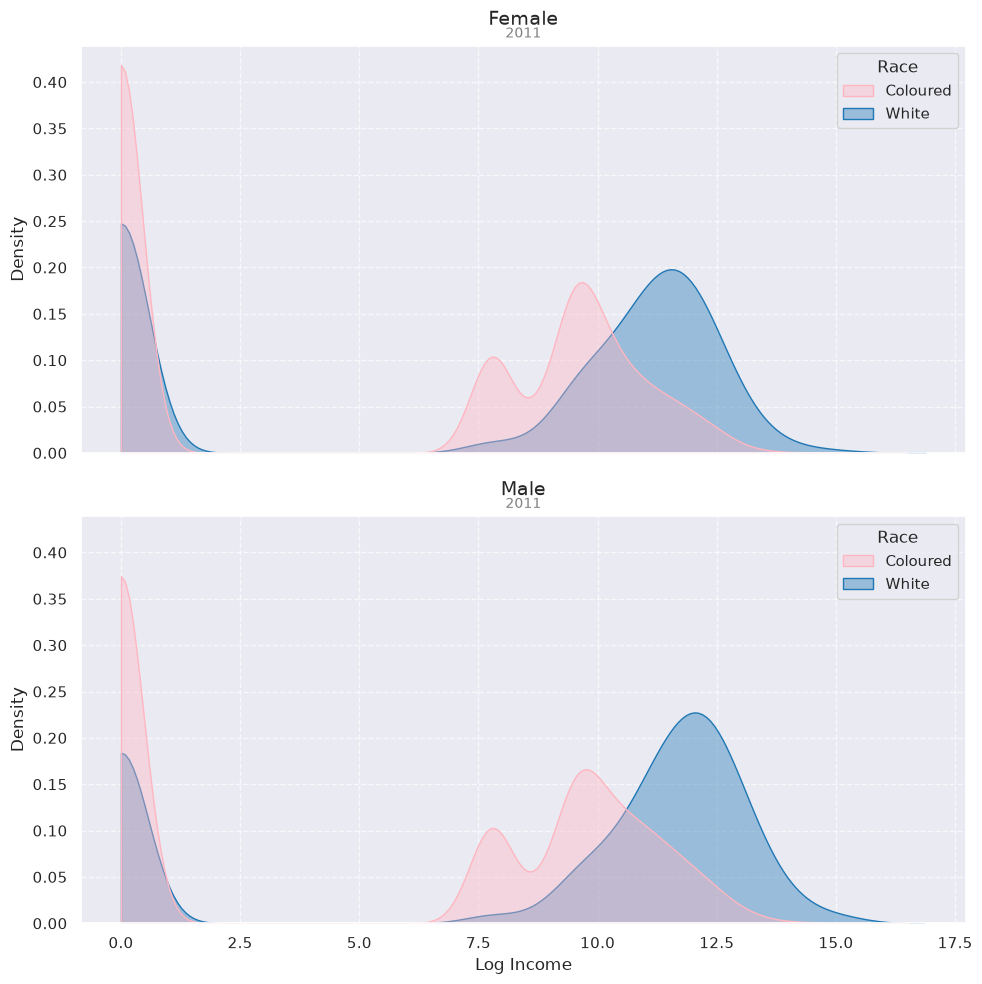

In [35]:
# plots
sns.set_theme(style="darkgrid")

df_filtered['P05_POP_GROUP'] = df_filtered['P05_POP_GROUP'].cat.remove_unused_categories()

# color palette
custom_palette = {'Coloured': '#FFB6C1', 'White': '#1F77B4'}  
# 2x1 grid layout
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True, sharey=True)

genders = ['Female', 'Male']

for i, gender in enumerate(genders):
    ax = axes[i]
    # filter for the specific gender loop
    subset = df_filtered[df_filtered['F03_SEX'] == gender]
    
    sns.kdeplot(
        data=subset,
        x='log_income',
        hue='P05_POP_GROUP',
        palette=custom_palette,
        fill=True,
        alpha=0.4,
        ax=ax,
        common_norm=False,
        clip=(0, None) # don't allow negative vals 
    )
    # formatting
    ax.get_legend().set_title("Race")
    ax.grid(True, linestyle='--', alpha=0.7, color='white')
    ax.set_title(gender, fontsize=14, pad=15)
    ax.set_xlabel('Log Income')  
    ax.set_ylabel('Density', fontsize=12)
    # subtitle
    ax.text(0.5, 1.02, '2011', transform=ax.transAxes, ha='center', fontsize=10, color='gray')

plt.savefig("images/2011_income.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

**Data Summary Tables**

In [36]:
# years of education mapping
edu_map = {
    98: 0,   # No schooling
    0:  0,   # Grade 0
    1:  1,   # Grade 1/sub A
    2:  2,   # Grade 2/sub B
    3:  3,   # Grade 3/std 1
    4:  4,   # Grade 4/std 2
    5:  5,   # Grade 5/std 3
    6:  6,   # Grade 6/std 4
    7:  7,   # Grade 7/std 5
    8:  8,   # Grade 8/std 6/form 1
    9:  9,   # Grade 9/std 7/form 2
    10: 10,  # Grade 10/std 8/form 3
    11: 11,  # Grade 11/std 9/form 4
    12: 12,  # Grade 12/std 10/form 5 (Matric)
    
    # Technical / Vocational Track
    13: 10,  # NTC I / N1
    14: 11,  # NTC II / N2
    15: 12,  # NTC III / N3
    16: 13,  # N4 / NTC 4
    17: 13,  # N5 / NTC 5
    18: 14,  # N6 / NTC 6
    
    # Certificates and Diplomas
    19: 10,  # Certificate with less than Grade 12
    20: 11,  # Diploma with less than Grade 12
    21: 13,  # Certificate with Grade 12 (1 year post-matric)
    22: 14,  # Diploma with Grade 12 (2 years post-matric)
    23: 15,  # Higher Diploma (3 years post-matric)
    24: 16,  # Post Higher Diploma (Masters/Doctoral diploma)
    
    # Tertiary / Degrees
    25: 15,  # Bachelors degree
    26: 16,  # Bachelors degree and Post graduate diploma
    27: 16,  # Honours degree
    28: 17,  # Higher degree (masters, doctorate)
    
    # Missing / Unspecified
    29: np.nan # Other
}

# apply mapping
df_filtered['edu_years'] = df_filtered['P20_EDULEVEL'].map(edu_map)

In [37]:
# rename column
df_filtered = df_filtered.rename(columns={'F03_SEX': 'Sex'})

# dummy variables
df_filtered['is_employed'] = (df_filtered['P23A_EMPLOYMENTSTATUS'] == 'Employed').astype(int)
df_filtered['is_white'] = (df_filtered['P05_POP_GROUP'] == 'White').astype(int)
df_filtered['P20_EDULEVEL'] = df_filtered['P20_EDULEVEL'].astype(float)

# table rows
vars_to_analyze = {
    'is_white': 'White',
    'P20_EDULEVEL': 'Years of education',
    'is_employed': 'Employed',
    'log_income': 'Log income'
}

# group by gender & calculate mean
summary = df_filtered.groupby('Sex')[list(vars_to_analyze.keys())].agg(['mean', 'std', 'count'])

summary = summary.stack(level=0)

summary = summary.rename(index=vars_to_analyze)
summary.columns = ['Mean', 'SD', 'N']

summary = summary.swaplevel(0, 1).sort_index(level=0)

# formatting
formatted_table = summary.copy()
formatted_table['Mean'] = formatted_table['Mean'].map('{:,.2f}'.format)
formatted_table['SD'] = formatted_table['SD'].map('{:,.2f}'.format)
formatted_table['N'] = formatted_table['N'].map('{:,}'.format)

display(formatted_table)

Mean     SD        N
                   Sex                          
Employed           Female   0.31   0.46  232,424
                   Male     0.38   0.49  214,505
Log income         Female   5.74   5.21  226,145
                   Male     6.52   5.32  207,721
White              Female   0.33   0.47  232,424
                   Male     0.32   0.47  214,505
Years of education Female  13.71  16.44  210,334
                   Male    13.70  16.46  191,359

In [19]:
# export table
dfi.export(formatted_table, 'images/formatted_table_2011.png', table_conversion='matplotlib')

## Ordinary Least Squares Regression (2011-only)

TL;DR: OLS aims to find a single straight line drawn through the cloud of data points that summarizes the general relationship Y = Intercept + (Slope * X). The vertical distance between a data point and the line is the residual (error): Actual Value - Predicted Value. OLS seeks to minimize the Sum of Squared Residuals (SSR). 

$$\text{Log Income}_i = \beta_0 + \beta_1 \text{White}_i + \beta_2 \text{EduYears}_i + \beta_3 \text{Age}_i + \beta_4 \text{Age}_i^2 + \beta_5 \text{Employed}_i + \varepsilon_i$$

In [26]:
df_filtered.head()

,P01_YEAR,Sex,P05_POP_GROUP,P16_INCOME,P20_EDULEVEL,P23A_EMPLOYMENTSTATUS,real_income,log_income,is_employed,is_white,edu_years
0,1957,Female,Coloured,4.0,7.0,Employed,14400.0,9.575053,1,0,7.0
1,1978,Male,Coloured,1.0,8.0,Unemployed,0.0,0.000000,0,0,8.0
2,1987,Female,Coloured,1.0,6.0,Unemployed,0.0,0.000000,0,0,6.0
3,2007,Female,Coloured,2.0,NaN,NaN,2400.0,7.783641,0,0,NaN
4,2010,Male,Coloured,2.0,NaN,NaN,2400.0,7.783641,0,0,NaN


Centered the year of birth (YOB) around zero

In [49]:
# filter missing values
df_regression = df_filtered[
    (df_filtered['real_income'] > 0) & 
    (df_filtered['P20_EDULEVEL'].notna()) &
    (df_filtered['P23A_EMPLOYMENTSTATUS'].notna())
].copy()

# birth year wrangling
df_filtered['yob_centered'] = df_filtered['P01_YEAR'] - df_filtered['P01_YEAR'].mean()
df_regression['yob_centered'] = df_filtered['P01_YEAR'] - df_filtered['P01_YEAR'].mean()

# log income for positive earners only
df_regression['log_income'] = np.log(df_regression['real_income'])

# partition by gender
df_women = df_regression[df_regression['Sex'] == 'Female']
df_men = df_regression[df_regression['Sex'] == 'Male']

*Why use `cov_type='HC1'`?*

Running OLS without specififying a covariance type results in Python assuming homoskedasticity. HC1 (Heteroskedasticity-Consistent standard errors) prevents the regression from claiming coefficients are statistically significant when they aren't. 

Link: https://www.investopedia.com/terms/h/homoskedastic.asp

- Homoskedasticity is constant variance in the error term of a regression model. In  other terms, it implies that the error term does not vary much as the value of the predictor variable changes. 

*Why include the $YOB^2$ term?*

The relationship between birth year and income is non-linear and a standard linear term alone cannot capture that relationship. 

![Example](images/age_income_relationship.png)

In [28]:
formula = "log_income ~ is_white + is_employed + edu_years + yob_centered + I(yob_centered**2)"

print("=========================================")
print("2011 WOMEN OLS")
print("=========================================\n")
model_women = smf.ols(formula, data=df_women).fit(cov_type='HC1')
print(model_women.summary())

2011 WOMEN OLS

                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                 1.778e+04
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        22:10:51   Log-Likelihood:            -1.5397e+05
No. Observations:              110480   AIC:                         3.080e+05
Df Residuals:                  110474   BIC:                         3.080e+05
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept       

In [29]:
# for graph purposes. . . 
rd_data = (
    df_women.groupby('yob_centered')['is_white']
    .mean()
    .reset_index()
    .rename(columns={'is_white': 'share_of_whites'})
)

# view dataset
rd_data.head()

,yob_centered,share_of_whites
0,-76.512464,0.500000
1,-75.512464,0.333333
2,-74.512464,0.714286
3,-73.512464,0.200000
4,-72.512464,0.200000


In [35]:
df_filtered['P01_YEAR'].mean()

np.float64(1976.5124639484125)

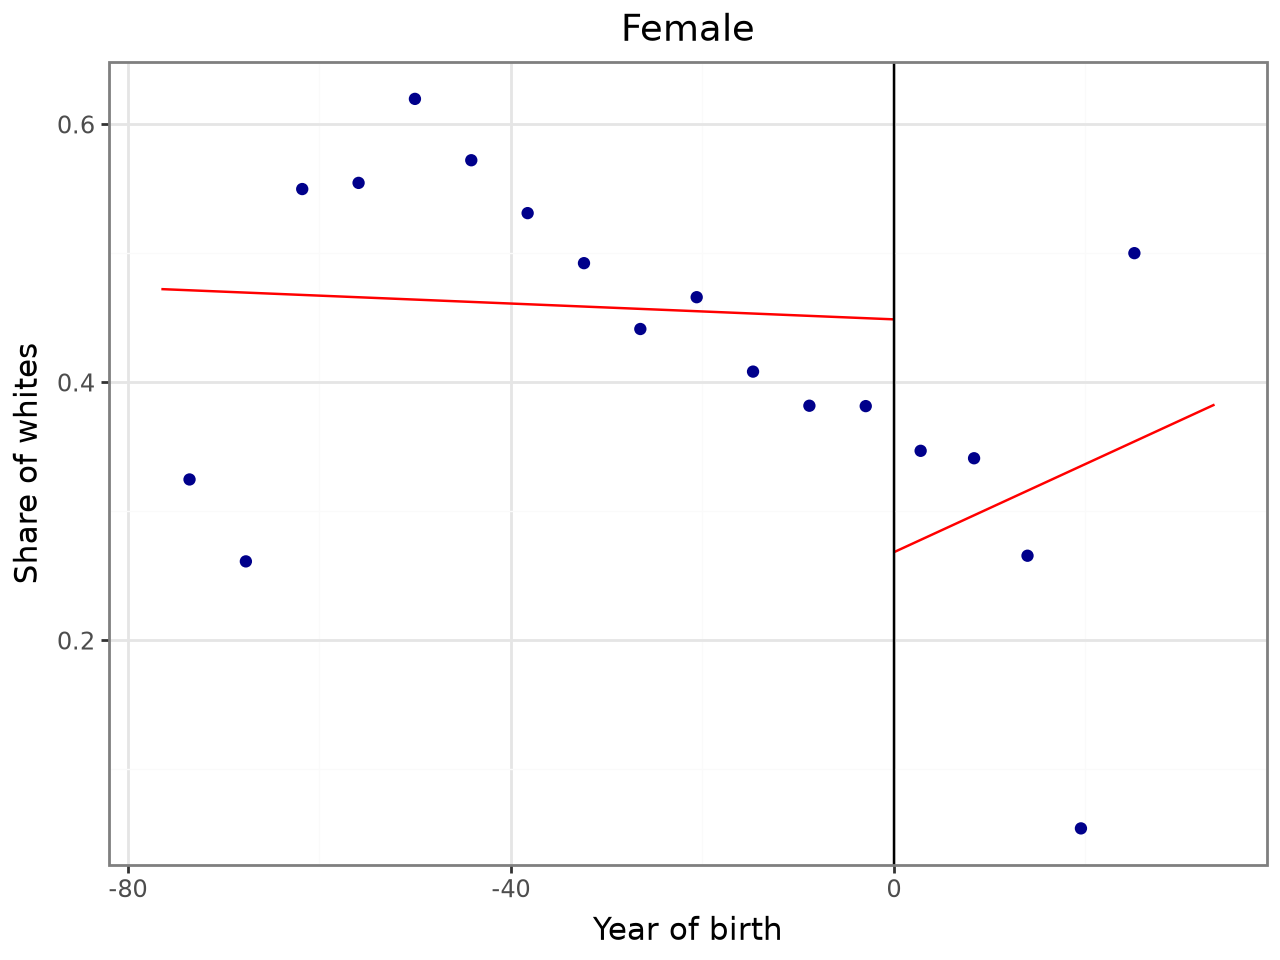

/home/erinbrzusek/anaconda3/envs/dsan5650/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/erinbrzusek/anaconda3/envs/dsan5650/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: images/rd_female_2011.png


In [30]:
rdplot_res = rdrobust.rdplot(
    y=rd_data['share_of_whites'], 
    x=rd_data['yob_centered'], 
    c=0, 
    p=1,
    title="Female",
    x_label="Year of birth",
    y_label="Share of whites"
)

fig = rdplot_res.rdplot
fig.save("images/rd_female_2011.png", dpi=300)

In [34]:
print("\n\n=========================================")
print("2011 MEN OLS")
print("=========================================\n")
model_men = smf.ols(formula, data=df_men).fit(cov_type='HC1')
print(model_men.summary())



2011 MEN OLS

                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.494
Model:                            OLS   Adj. R-squared:                  0.494
Method:                 Least Squares   F-statistic:                 2.249e+04
Date:                Tue, 21 Jul 2026   Prob (F-statistic):               0.00
Time:                        22:16:47   Log-Likelihood:            -1.5752e+05
No. Observations:              111172   AIC:                         3.150e+05
Df Residuals:                  111166   BIC:                         3.151e+05
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept       

In [32]:
rd_data = (
    df_men.groupby('yob_centered')['is_white']
    .mean()
    .reset_index()
    .rename(columns={'is_white': 'share_of_whites'})
)

rd_data.head()

,yob_centered,share_of_whites
0,-76.512464,1.00
1,-75.512464,0.25
2,-74.512464,0.50
3,-73.512464,0.50
4,-72.512464,0.25


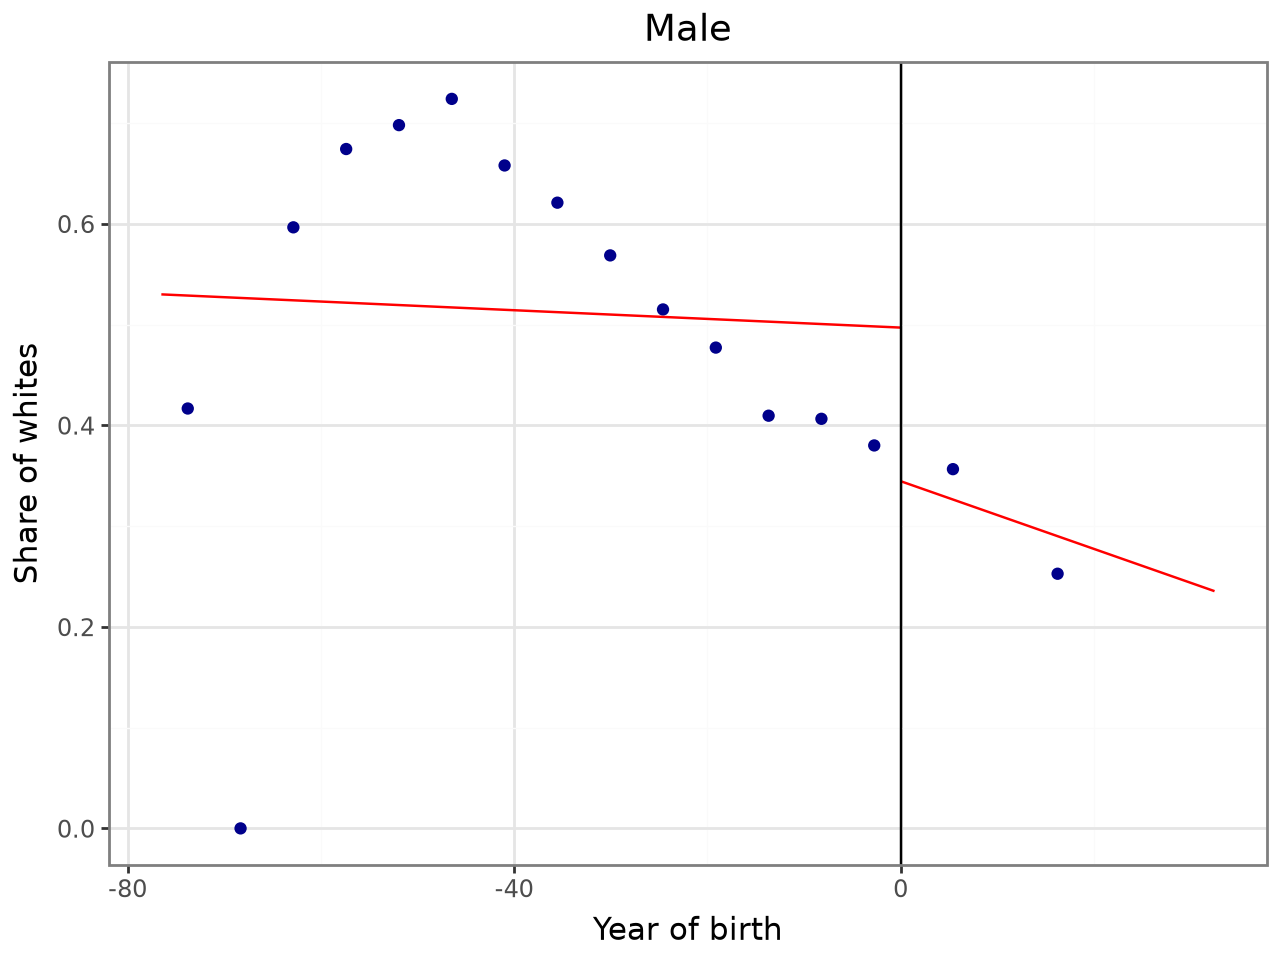

/home/erinbrzusek/anaconda3/envs/dsan5650/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/erinbrzusek/anaconda3/envs/dsan5650/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: images/rd_male_2011.png


In [33]:
rdplot_res = rdrobust.rdplot(
    y=rd_data['share_of_whites'], 
    x=rd_data['yob_centered'], 
    c=0, 
    p=1, 
    title="Male",
    x_label="Year of birth",
    y_label="Share of whites"
)

fig = rdplot_res.rdplot
fig.save("images/rd_male_2011.png", dpi=300)

In [ ]:
# comparison table

stargazer = Stargazer([model_men, model_women])
stargazer.custom_columns(['Men', 'Women'], [1, 1])
stargazer.rename_covariates({
    'is_white': 'White',
    'is_employed': 'Employed',
    'edu_years': 'Years of Education',
    'yob_centered': 'YOB (Centered)',
    'I(yob_centered ** 2)': 'YOB Squared',
    'Intercept': 'Constant'
})

# Display in notebook
stargazer

In [ ]:
# export to png
html_str = stargazer.render_html()

df_table = pd.read_html(io.StringIO(html_str))[0]

df_table = df_table.fillna('')

dfi.export(
    df_table, 
    'images/stargazer_2011_ols.png', 
    table_conversion='matplotlib'
)

## 2001 Census Data

In [39]:
path = "data/SA Census 2001 Person_stata_pr1-5/SA Census 2001 Person_stata_pr1-5/SA Census 2001 Person_v1.1_20111024_pr1_5.dta"

cols = ['p02_day', 'p02_mth', 'p02_yr', 'p02_age', 'p03_sex', 'p06_race', 'p17_educ', 'der10_em', 'p22_incm']

reader = pd.read_stata(
    path, 
    columns=cols,
    chunksize=100000, 
    convert_categoricals=False
)

df_list = []
for chunk in reader:
    for col in chunk.columns:
        chunk[col] = pd.to_numeric(chunk[col], downcast='integer')
        
    df_list.append(chunk)

In [40]:
df_2001 = pd.concat(df_list, ignore_index=True)
df_2001.head()

,p02_day,p02_mth,p02_yr,p02_age,p03_sex,p06_race,p17_educ,der10_em,p22_incm
0,11,1,1936,65,1,3,8,1,5
1,11,11,1935,65,2,3,7,3,3
2,24,6,1947,54,2,1,99,3,3
3,3,1,1964,37,2,1,99,2,1
4,9,3,1980,21,2,1,12,1,2


**Categorical Variable Explanations**

Link: https://www.datafirst.uct.ac.za/dataportal/index.php/catalog/96/data-dictionary/F10?file_name=SA%20Census%202001%20Person_v1.1_20111024

In [41]:
# categorical variable mapping
race_map = {1: 'Black African', 2: 'Coloured', 3: 'Indian or Asian', 4: 'White'}
emp_map = {0: 'Not applicable', 1: 'Employed', 2: 'Unemployed', 3: 'Not economically active'}
gen_map = {1: 'Male', 2: 'Female'}

df_2001['p03_sex'] = df_2001['p03_sex'].map(gen_map).astype('category')
df_2001['p06_race'] = df_2001['p06_race'].map(race_map).astype('category')
df_2001['der10_em'] = df_2001['der10_em'].map(emp_map).astype('category')

# income midpoints
midpoint_map_2001 = {
    1: 0,          # No income
    2: 200.5,      # R1 - R400
    3: 600.5,      # R401 - R800
    4: 1200.5,     # R801 - R1600
    5: 2400.5,     # R1601 - R3200
    6: 4800.5,     # R3201 - R6400
    7: 9600.5,     # R6401 - R12800
    8: 19200.5,    # R12801 - R25600
    9: 38400.5,    # R25601 - R51200
    10: 76800.5,   # R51201 - R102400
    11: 153600.5,  # R102401 - R204800
    12: 307201.5   # R204801+ (Lower bound * 1.5)
}

df_2001['real_income'] = df_2001['p22_incm'].map(midpoint_map_2001).astype(float)

### Inflation

Using Consumer Price Index (CPI), I will account for inflation between 2001 and 2011. 

Link: https://tradingeconomics.com/south-africa/consumer-price-index-cpi

**Statistics South Africa**

- 2001 Release: https://www.statssa.gov.za/publications/P01411/P01411December2001.pdf
- 2011 Release: https://www.gov.za/sites/default/files/gcis_document/201409/34858gen909.pdf

In [42]:
# inflate the 2001 Rand
df_2001['adj_income_2011'] = df_2001['real_income'] * 1.775

In [43]:
# log transformation
df_2001['adj_log_income'] = np.log1p(df_2001['adj_income_2011'])

In [15]:
df_2001.head()

,p02_day,p02_mth,p02_yr,p02_age,p03_sex,p06_race,p17_educ,der10_em,p22_incm,real_income,adj_income_2011,adj_log_income
0,11,1,1936,65,Male,Indian or Asian,8,Employed,5,2400.5,4260.8875,8.357467
1,11,11,1935,65,Female,Indian or Asian,7,Not economically active,3,600.5,1065.8875,6.972501
2,24,6,1947,54,Female,Black African,99,Not economically active,3,600.5,1065.8875,6.972501
3,3,1,1964,37,Female,Black African,99,Unemployed,1,0.0,0.0000,0.000000
4,9,3,1980,21,Female,Black African,12,Employed,2,200.5,355.8875,5.877421


In [44]:
# filter
df_2001 = df_2001[df_2001['p06_race'].isin(['Coloured', 'White'])].copy()

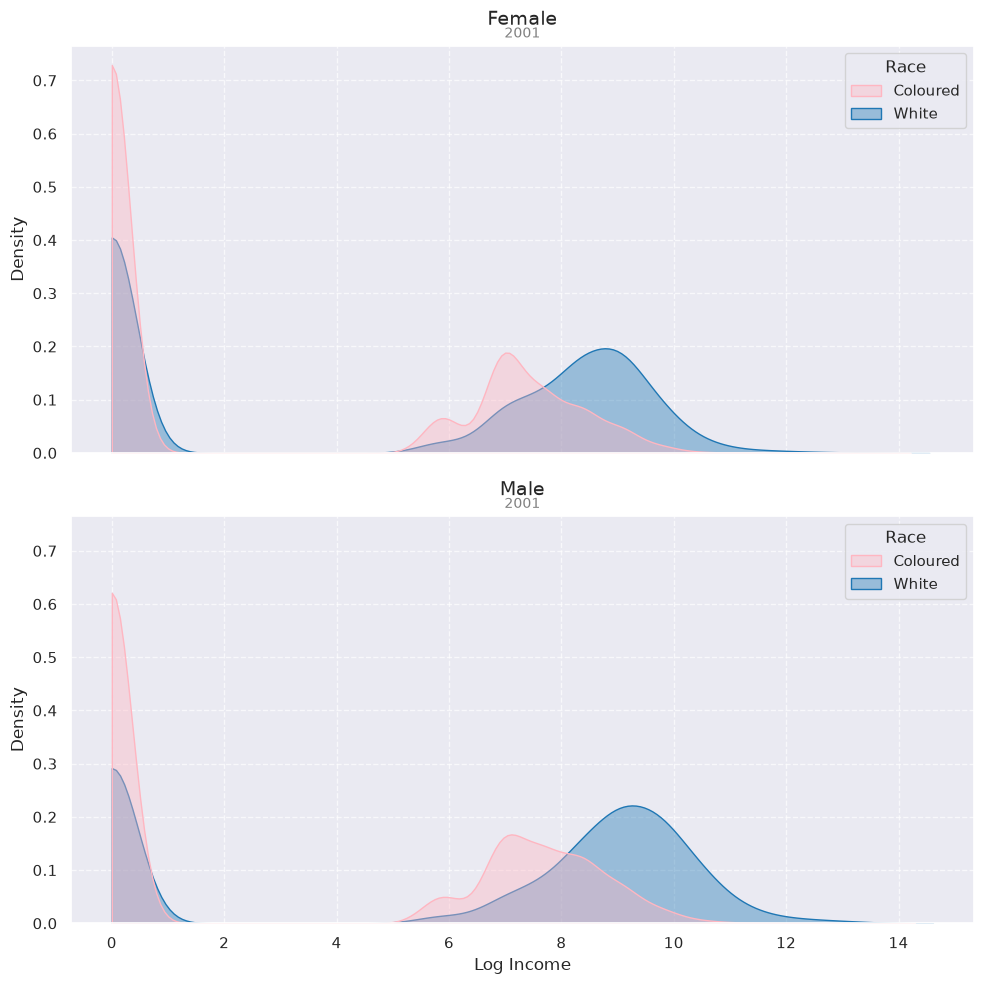

In [45]:
sns.set_theme(style="darkgrid")

df_2001['p06_race'] = df_2001['p06_race'].cat.remove_unused_categories()

# color
custom_palette = {'Coloured': '#FFB6C1', 'White': '#1F77B4'}  

# 2x1 grid layout
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 10), sharex=True, sharey=True)

genders = ['Female', 'Male']

for i, gender in enumerate(genders):
    ax = axes[i]
    # gender loop
    subset = df_2001[df_2001['p03_sex'] == gender]
    
    sns.kdeplot(
        data=subset,
        x='adj_log_income',
        hue='p06_race',
        palette=custom_palette,
        fill=True,
        alpha=0.4,
        ax=ax,
        common_norm=False,
        clip=(0, None) # don't allow negative vals 
    )
    
    # formatting
    ax.get_legend().set_title("Race")
    ax.grid(True, linestyle='--', alpha=0.7, color='white')
    ax.set_title(gender, fontsize=14, pad=15)
    ax.set_xlabel('Log Income')  
    ax.set_ylabel('Density', fontsize=12)
    
    # subtitle indicating year
    ax.text(0.5, 1.02, '2001', transform=ax.transAxes, ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig("images/2001_income.png", dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# dummy variables
df_2001['edu_years'] = df_2001['p17_educ'].replace(99, 0).astype(float)

df_2001['is_employed'] = (df_2001['der10_em'] == 'Employed').astype(int)
df_2001['is_white'] = (df_2001['p06_race'] == 'White').astype(int)

# table rows
vars_to_analyze = {
    'is_white': 'White',
    'edu_years': 'Years of education',
    'is_employed': 'Employed',
    'adj_log_income': 'Log income'
}

# group by gender
summary = df_2001.groupby('p03_sex')[list(vars_to_analyze.keys())].agg(['mean', 'std', 'count'])

summary = summary.stack(level=0)
summary = summary.rename(index=vars_to_analyze)
summary.columns = ['Mean', 'SD', 'N']

# reorder index 
summary = summary.swaplevel(0, 1).sort_index(level=0)

# formatting
formatted_table = summary.copy()
formatted_table['Mean'] = formatted_table['Mean'].map('{:,.2f}'.format)
formatted_table['SD'] = formatted_table['SD'].map('{:,.2f}'.format)
formatted_table['N'] = formatted_table['N'].map('{:,}'.format)

display(formatted_table)

Mean    SD        N
                   p03_sex                     
Employed           Female   0.29  0.45  242,299
                   Male     0.39  0.49  222,561
Log income         Female   3.48  3.99  242,299
                   Male     4.28  4.27  222,561
White              Female   0.34  0.47  242,299
                   Male     0.34  0.47  222,561
Years of education Female   7.87  4.91  242,299
                   Male     7.84  5.11  222,561

In [20]:
# save table as .png
dfi.export(formatted_table, 'images/formatted_table_2001.png', table_conversion='matplotlib')

## Pooled Cross-Section Analysis (2001 and 2011)

$$\text{Log Income}_{it} = \beta_0 + \beta_1 \text{White}_{it} + \beta_2 \text{Year2011}_t + \beta_3 (\text{White}_{it} \times \text{Year2011}_t) + \boldsymbol{\gamma} \mathbf{X}_{it} + \varepsilon_{it}$$

In [47]:
# birth year wrangling p.2
df_2001['yob_centered'] = df_2001['p02_yr'] - df_filtered['P01_YEAR'].mean()

df_2001.head()

,p02_day,p02_mth,p02_yr,p02_age,p03_sex,p06_race,p17_educ,der10_em,p22_incm,real_income,adj_income_2011,adj_log_income,edu_years,is_employed,is_white,yob_centered
348,13,1,1972,29,Male,Coloured,10,Not economically active,1,0.0,0.0000,0.000000,10.0,0,0,-4.512464
350,30,5,1952,49,Male,White,15,Employed,7,9600.5,17040.8875,9.743430,15.0,1,1,-24.512464
351,8,10,1956,45,Female,White,12,Not economically active,5,2400.5,4260.8875,8.357467,12.0,0,1,-20.512464
352,23,10,1927,73,Female,White,8,Not applicable,3,600.5,1065.8875,6.972501,8.0,0,1,-49.512464
353,10,8,1950,51,Male,White,10,Not economically active,5,2400.5,4260.8875,8.357467,10.0,0,1,-26.512464


In [50]:
df_2011 = df_filtered.copy()

df_2011.head()

,P01_YEAR,Sex,P05_POP_GROUP,P16_INCOME,P20_EDULEVEL,P23A_EMPLOYMENTSTATUS,real_income,log_income,edu_years,is_employed,is_white,yob_centered
0,1957,Female,Coloured,4.0,7.0,Employed,14400.0,9.575053,7.0,1,0,-19.512464
1,1978,Male,Coloured,1.0,8.0,Unemployed,0.0,0.000000,8.0,0,0,1.487536
2,1987,Female,Coloured,1.0,6.0,Unemployed,0.0,0.000000,6.0,0,0,10.487536
3,2007,Female,Coloured,2.0,NaN,NaN,2400.0,7.783641,NaN,0,0,30.487536
4,2010,Male,Coloured,2.0,NaN,NaN,2400.0,7.783641,NaN,0,0,33.487536


In [51]:
# 2001 relevant cols
cols_2001 = {
    'adj_log_income': 'log_real_income',
    'is_white': 'is_white',
    'is_employed': 'is_employed',
    'edu_years': 'edu_years',
    'yob_centered': 'yob_centered',
    'p03_sex': 'sex'
}

# 2011 relevant cols
cols_2011 = {
    'log_income': 'log_real_income',
    'is_white': 'is_white',
    'is_employed': 'is_employed',
    'edu_years': 'edu_years',
    'yob_centered': 'yob_centered',
    'Sex': 'sex'
}

# subsets
df_2001_clean = df_2001[list(cols_2001.keys())].rename(columns=cols_2001)
df_2011_clean = df_2011[list(cols_2011.keys())].rename(columns=cols_2011)

# year indicator flags
df_2001_clean['year'] = 2001
df_2001_clean['year_2011'] = 0

df_2011_clean['year'] = 2011
df_2011_clean['year_2011'] = 1

# binary sex flags
df_2001_clean['is_male'] = np.where(df_2001_clean['sex'].astype(str).str.lower().str.startswith('m'), 1, 0)
df_2011_clean['is_male'] = np.where(df_2011_clean['sex'].astype(str).str.lower().str.startswith('m'), 1, 0)

df_2001_clean = df_2001_clean.drop(columns=['sex'])
df_2011_clean = df_2011_clean.drop(columns=['sex'])

# concatenate
df_pooled = pd.concat([df_2001_clean, df_2011_clean], ignore_index=True)

In [53]:
# view results
print("pooled shape:", df_pooled.shape)
df_pooled.head()

pooled shape: (911789, 8)


,log_real_income,is_white,is_employed,edu_years,yob_centered,year,year_2011,is_male
0,0.000000,0,0,10.0,-4.512464,2001,0,1
1,9.743430,1,1,15.0,-24.512464,2001,0,1
2,8.357467,1,0,12.0,-20.512464,2001,0,0
3,6.972501,1,0,8.0,-49.512464,2001,0,0
4,8.357467,1,0,10.0,-26.512464,2001,0,1


In [55]:
# pooled cross-section formula
formula = """
log_real_income ~ is_white * year_2011 
                + is_employed 
                + edu_years 
                + yob_centered 
                + I(yob_centered**2)
"""

# fit the model (men)
model_pooled_men = smf.ols(
    formula=formula, 
    data=df_pooled[df_pooled['is_male'] == 1]
).fit(cov_type='HC1')

# fit the model (women)
model_pooled_women = smf.ols(
    formula=formula, 
    data=df_pooled[df_pooled['is_male'] == 0]
).fit(cov_type='HC1')

In [56]:
# output for men
print("=== POOLED OLS RESULTS: MEN ===")
print(model_pooled_men.summary())

=== POOLED OLS RESULTS: MEN ===
                            OLS Regression Results                            
Dep. Variable:        log_real_income   R-squared:                       0.667
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                 1.769e+05
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:00:02   Log-Likelihood:            -1.0188e+06
No. Observations:              412949   AIC:                         2.038e+06
Df Residuals:                  412941   BIC:                         2.038e+06
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------


In [57]:
# output for women
print("\n=== POOLED OLS RESULTS: WOMEN ===")
print(model_pooled_women.summary())


=== POOLED OLS RESULTS: WOMEN ===
                            OLS Regression Results                            
Dep. Variable:        log_real_income   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                 1.444e+05
Date:                Wed, 22 Jul 2026   Prob (F-statistic):               0.00
Time:                        23:00:05   Log-Likelihood:            -1.1458e+06
No. Observations:              451808   AIC:                         2.292e+06
Df Residuals:                  451800   BIC:                         2.292e+06
Df Model:                           7                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------